In [1]:
import matplotlib.pyplot as plt
import numpy as np

from oumean_range_tuner import OUMeanRangeTuner

c:\Users\aleks\.conda\envs\netpyne_batch\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


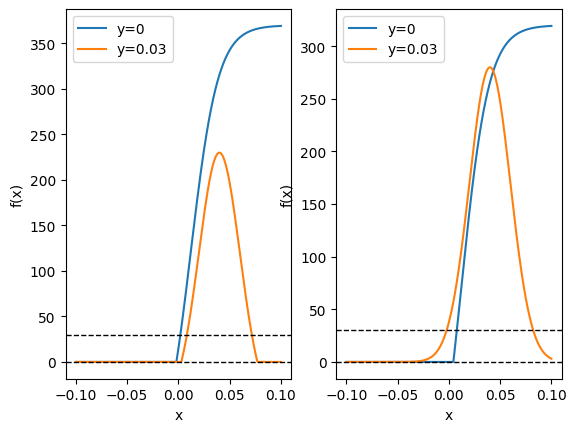

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Blue curve: logistic (saturating) ----------
def blue_model(x, A, k, x0, C):
    """y = C + A / (1 + exp(-k * (x - x0)))"""
    x = np.asarray(x, dtype=float)
    return np.maximum(0, C + A / (1.0 + np.exp(-k * (x - x0))))

# ---------- Orange curve: gated Gaussian (rise-then-fall) ----------
def logistic(z):
    return 1.0 / (1.0 + np.exp(-z))

def orange_model(x, A, mu, sigma, gate_k, gate_x0, C):
    """
    y = C + A * exp(-0.5 * ((x - mu)/sigma)**2) * logistic(gate_k * (x - gate_x0))
    """
    x = np.asarray(x, dtype=float)
    gauss = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    gate = logistic(gate_k * (x - gate_x0))
    return np.maximum(0, C + A * gauss * gate)

# Fit from your plot
ORANGE_PARAMS = dict(A=280, mu=0.04, sigma=0.02,
                     gate_k=197.26, gate_x0=-0.1, C=-50)

# Fit from your plot (constants you can reuse)
BLUE_PARAMS = dict(A=500, k=75, x0=0.012, C=-130)

def f(x, y, n):
    if y > 1e-6:
        par = ORANGE_PARAMS.copy()
        par['C'] += n * 50
        return orange_model(x, **par)
    else:
        par = BLUE_PARAMS.copy()
        par['C'] -= n * 50
        return blue_model(x, **par)

# ---------- Example ----------
xs = np.linspace(-0.1, 0.1, 400)

plt.switch_backend('inline')
plt.figure()

for n in range(2):
    plt.subplot(1, 2, n + 1)
    for y in [0, 0.03]:
        plt.plot(xs, f(xs, y, n), label=f'y={y}')
    plt.axhline(0, ls="--", lw=1, c="k")
    plt.axhline(30, ls="--", lw=1, c="k")
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("f(x)")
plt.show()


In [3]:
plt.close('all')

In [20]:
from pathlib import Path

plt.switch_backend('qt5agg')

range_tuner = OUMeanRangeTuner(
    ['PV2', 'PV3'],
    ou_std_vals=[0, 0.03],
    num_ou_mean_vals=10,
    ou_mean_range_start=(-0.1, 0.1),
    rate_limits=(0.2, 30),
    #rate_limits = {
    #    'pop1': (1, 25),
    #    'pop2': (5, 20)
    #},
    tolerance=0.05,
    dummy_mode=True,
    dummy_func=f
)

dirpath_figs = Path(r'D:\WORK\Salvador\repo\model_tuner\test_data\range_search'
                    r'\subnet_state1_mech1_nosub_wmult_0.1\exp_test_dummy\opt_figs')
final_run = False

for iter_num in range(20):
    print(f'ITER: {iter_num}', flush=True)

    range_tuner.process_sim_results(None, None, None)
    range_tuner.plot_rates(dirpath_figs, iter_num)

    if final_run:
        print('DONE', flush=True)
        break
    elif range_tuner.is_done():
        print('ALL RANGES FOUND -> FINAL RUN', flush=True)
        range_tuner.final_step()
        final_run = True
    else:
        range_tuner.step()

plt.close('all')

ITER: 0
ITER: 1
ITER: 2
ITER: 3
ALL RANGES FOUND -> FINAL RUN
ITER: 4
DONE
